In [1]:
# =============================================================================
# Complete CoLFI analysis for Weyl-type f(Q,T) gravity (done on CPU)
# =============================================================================

import numpy as np
from scipy.integrate import quad
import colfi.nde as nde
import corner
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Defining the f(Q,T) model simulator (used by CoLFI)
# -----------------------------------------------------------------------------

class FQTModel:
    """
    Simulator class for the Weyl-type f(Q,T) gravity model.
    It computes the total chi-squared for given parameters (q0, q1, Om0, M_B).
    """
    def __init__(self, z_ohd, H_ohd, H_err, z_sn, mb, mb_err,
                 dm_data, dh_data, dv_data, H0=70, rs=147.5):
        self.z_ohd = z_ohd
        self.H_ohd = H_ohd
        self.H_err = H_err
        self.z_sn = z_sn
        self.mb = mb
        self.mb_err = mb_err
        self.dm_data = dm_data
        self.dh_data = dh_data
        self.dv_data = dv_data
        self.H0 = H0
        self.rs = rs
        self.c = 299792.458  # km/s

    # ---------- Cosmological functions ----------
    def hubble_z(self, z, q0, q1):
        return self.H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1/2)

    def comoving_distance(self, z, q0, q1):
        c = self.c
        def integrand(zp):
            return c / self.hubble_z(zp, q0, q1)
        if np.isscalar(z):
            return quad(integrand, 0, z)[0]
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            res[i] = quad(integrand, 0, zi)[0]
        return res

    def angular_diameter_distance(self, z, q0, q1):
        return self.comoving_distance(z, q0, q1) / (1 + z)

    def luminosity_distance(self, z, q0, q1):
        c = self.c
        if np.isscalar(z):
            def integrand(zp):
                return 1.0 / self.hubble_z(zp, q0, q1)
            integral = quad(integrand, 0, z)[0]
            return c * (1 + z) * integral
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return 1.0 / self.hubble_z(zp, q0, q1)
            dL[i] = c * (1 + zi) * quad(integrand, 0, zi)[0]
        return dL

    def distance_modulus_theory(self, z, q0, q1):
        dL = self.luminosity_distance(z, q0, q1)
        return 5 * np.log10(dL) + 25

    def chi2_BAO(self, q0, q1):
        chi2 = 0.0
        for z, obs, err in self.dm_data:
            DC = self.comoving_distance(z, q0, q1)
            model = DC / self.rs
            chi2 += ((obs - model) / err)**2
        for z, obs, err in self.dh_data:
            H_val = self.hubble_z(z, q0, q1)
            model = (self.c / H_val) / self.rs
            chi2 += ((obs - model) / err)**2
        for z, obs, err in self.dv_data:
            DC = self.comoving_distance(z, q0, q1)
            DA = DC / (1 + z)
            H_val = self.hubble_z(z, q0, q1)
            DV = ((1 + z)**2 * DA**2 * self.c * z / H_val) ** (1/3)
            model = DV / self.rs
            chi2 += ((obs - model) / err)**2
        return chi2

    def compute_chi2(self, params):
        q0, q1, Om0, M_B = params
        H_model = self.hubble_z(self.z_ohd, q0, q1)
        chi2_ohd = np.sum(((self.H_ohd - H_model) / self.H_err)**2)
        mu_model = self.distance_modulus_theory(self.z_sn, q0, q1)
        chi2_sn = np.sum(((self.mb - M_B - mu_model) / self.mb_err)**2)
        chi2_bao = self.chi2_BAO(q0, q1)
        return chi2_ohd + chi2_sn + chi2_bao

    def simulate(self, params):
        """
        Required method for CoLFI. Must return a tuple/list where the second
        element (index 1) is the 1D array of observables.
        """
        chi2 = self.compute_chi2(params)
        # Return a tuple: (anything, observable_array)
        # CoLFI will access [1] to get the observables
        return (None, np.array([chi2]))


# -----------------------------------------------------------------------------
# 2. Loading all the data (OHD, Pantheon+, DESI BAO)
# -----------------------------------------------------------------------------

print("Loading data...")

# OHD
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f"  OHD: {len(z_ohd)} points")

# Pantheon+ (diagonal errors)
sn = np.genfromtxt(r'C:\Users\mriga\Downloads\Pantheon+SH0ES.dat',
                   names=True, dtype=None, encoding='utf-8')
z_sn = sn['zCMB']
mb_sn = sn['m_b_corr']
mb_err_sn = sn['m_b_corr_err_DIAG']
print(f"  Pantheon+: {len(z_sn)} supernovae (diagonal errors)")

# DESI BAO
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov_bao = np.loadtxt(cov_file)
dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0]); val = float(row[1]); qty = row[2]; err = np.sqrt(cov_bao[i,i])
    if 'DV_over_rs' in qty:
        dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty:
        dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty:
        dh_data.append([z, val, err])
dv_data = np.array(dv_data)
dm_data = np.array(dm_data)
dh_data = np.array(dh_data)
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements")

# -----------------------------------------------------------------------------
# 3. Instantiating the simulator 
# -----------------------------------------------------------------------------

simulator = FQTModel(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
                     dm_data, dh_data, dv_data, H0=70, rs=147.5)

# -----------------------------------------------------------------------------
# 4. Observed data (chi² from MCMC best-fit) 
# -----------------------------------------------------------------------------
best_fit_mcmc = np.array([-0.561, 0.717, 0.352, -19.357])
obs_chi2 = simulator.compute_chi2(best_fit_mcmc)
obs_data = np.array([[obs_chi2]])   # shape (1,1)
print(f"\nReference chi² (from MCMC best-fit): {obs_chi2:.2f}")

# -----------------------------------------------------------------------------
# 5. Defining the parameter space and priors (CoLFI format)
# -----------------------------------------------------------------------------

params_dict = {
    'q0':  [r'$q_0$', -0.8, -0.4],
    'q1':  [r'$q_1$', 0.5, 0.8],
    'Om0': [r'$\Omega_m$', 0.2, 0.5],
    'M_B': [r'$M_B$', -19.6, -19.0],
}
param_names = [key for key in params_dict.keys()]

# Initial guess for the parameter space (single point, not a 2D array)
init_params = np.array([-0.6, 0.7, 0.3, -19.4])   

# -----------------------------------------------------------------------------
# 6. Setting up and training CoLFI (CPU mode) 
# -----------------------------------------------------------------------------
print("\nSetting up CoLFI estimator (CPU mode)...")
predictor = nde.NDEs(
    obs_data=obs_data,
    model=simulator,
    param_names=param_names,
    params_dict=params_dict,
    nde_type='MNN',
    num_train=10000,
    num_vali=500,
    chain_n=3,
    chain_leng=10000,
    # No init_params or init_chain needed
)

print("\nStarting training ...")
predictor.train(path='colfi_training_results')
print("Training complete.")

# -----------------------------------------------------------------------------
# 7. INFERENCE AND PLOTS
# -----------------------------------------------------------------------------
print("\nGenerating posterior samples and plots...")
predictor.get_steps()      # show training steps (loss curves)
predictor.get_contours()   # corner plot of posterior
plt.show()

print("\nAll done. Posterior plots saved (or displayed).")

Loading data...
  OHD: 43 points
  Pantheon+: 1701 supernovae (diagonal errors)
  DESI BAO: 13 measurements

Reference chi² (from MCMC best-fit): 901.07

Setting up CoLFI estimator (CPU mode)...

Starting training ...
randn_num: 1.24026

######################### step 1 #########################
5000 sets of new samples to be simulated ...
Generating samples uniformly in a hypercube parameter space using uniform distribution
Simulating the sample: 200/5000
Simulating the sample: 400/5000
Simulating the sample: 600/5000
Simulating the sample: 800/5000
Simulating the sample: 1000/5000
Simulating the sample: 1200/5000
Simulating the sample: 1400/5000
Simulating the sample: 1600/5000
Simulating the sample: 1800/5000
Simulating the sample: 2000/5000
Simulating the sample: 2200/5000
Simulating the sample: 2400/5000
Simulating the sample: 2600/5000
Simulating the sample: 2800/5000
Simulating the sample: 3000/5000
Simulating the sample: 3200/5000
Simulating the sample: 3400/5000
Simulating the

IndexError: index 2 is out of bounds for axis 1 with size 1

Loading data...
  OHD: 43 points
  Pantheon+: 1701 supernovae (diagonal errors)
  DESI BAO: 13 measurements

Generating training data (this may take a few minutes)...
Generating 2000 training samples...
  Progress: 500/2000
  Progress: 1000/2000
  Progress: 1500/2000
  Progress: 2000/2000
Training data shape: X=(2000, 4), y=(2000,)

Training GP...
Optimized kernel: 31.6**2 * RBF(length_scale=[0.802, 1.11, 100, 1.64]) + WhiteKernel(noise_level=1e-06)

Optimizing GP emulator...

===== RESULTS =====
GP emulator best-fit: q0=-0.5610, q1=0.7170, Ωm=0.3520, M_B=-19.3570
GP predicted minimum χ² = 901.23

MCMC best-fit: q0=-0.561, q1=0.717, Ωm=0.352, M_B=-19.357
Actual χ² at MCMC best-fit = 901.07

Actual χ² at GP best-fit = 901.07
Generating 500 training samples...
  Progress: 500/500


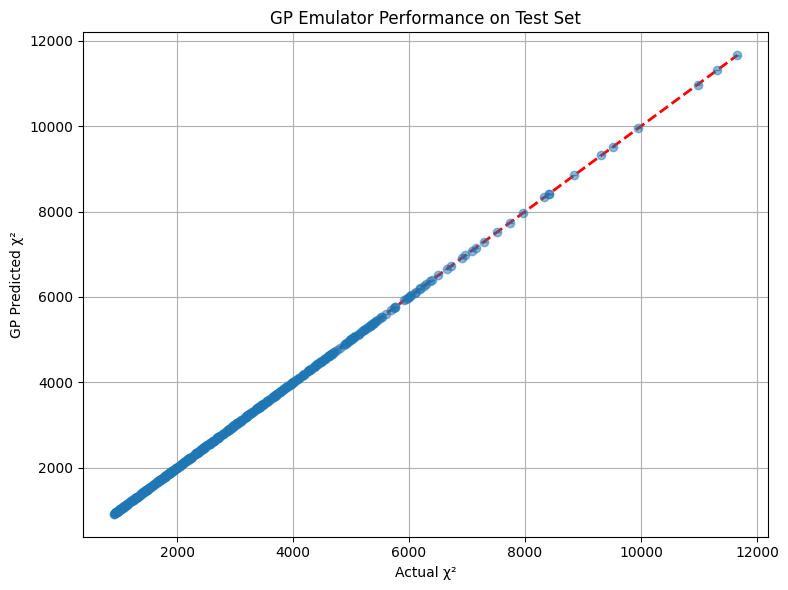


Generating approximate posterior from GP (1000 random starts)...


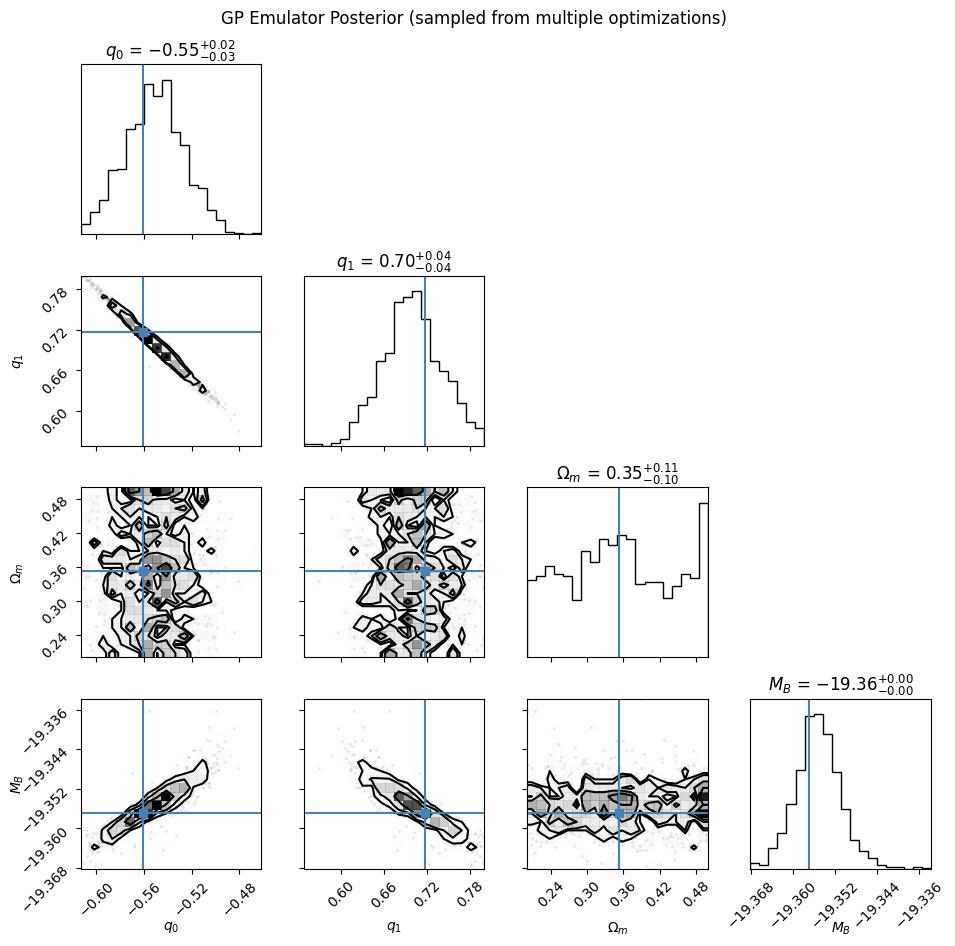


✅ GP emulator complete.


In [1]:
# =============================================================================
# GAUSSIAN PROCESS EMULATOR FOR F(Q,T) MODEL – ML vs MCMC COMPARISON
# =============================================================================

import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.optimize import minimize
from scipy.stats import qmc
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. DEFINING THE F(Q,T) MODEL SIMULATOR (all cosmology functions + data loading)
# -----------------------------------------------------------------------------

class FQTModel:
    """
    Simulator for the Weyl-type f(Q,T) gravity model.
    It computes the total chi-squared for given parameters (q0, q1, Om0, M_B)
    using OHD, Pantheon+ and DESI BAO data.
    """

    def __init__(self, z_ohd, H_ohd, H_err, z_sn, mb, mb_err,
                 dm_data, dh_data, dv_data, H0=70, rs=147.5):
        # Store data
        self.z_ohd = z_ohd
        self.H_ohd = H_ohd
        self.H_err = H_err
        self.z_sn = z_sn
        self.mb = mb
        self.mb_err = mb_err
        self.dm_data = dm_data
        self.dh_data = dh_data
        self.dv_data = dv_data
        self.H0 = H0
        self.rs = rs
        self.c = 299792.458  # speed of light in km/s

    # ---------- Cosmological functions ----------
    def hubble_z(self, z, q0, q1):
        """Hubble parameter from divergence-free deceleration parameter."""
        return self.H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1/2)

    def comoving_distance(self, z, q0, q1):
        """Comoving distance DC(z) in Mpc."""
        c = self.c
        def integrand(zp):
            return c / self.hubble_z(zp, q0, q1)
        if np.isscalar(z):
            return quad(integrand, 0, z)[0]
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            res[i] = quad(integrand, 0, zi)[0]
        return res

    def angular_diameter_distance(self, z, q0, q1):
        return self.comoving_distance(z, q0, q1) / (1 + z)

    def luminosity_distance(self, z, q0, q1):
        c = self.c
        if np.isscalar(z):
            def integrand(zp):
                return 1.0 / self.hubble_z(zp, q0, q1)
            integral = quad(integrand, 0, z)[0]
            return c * (1 + z) * integral
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return 1.0 / self.hubble_z(zp, q0, q1)
            dL[i] = c * (1 + zi) * quad(integrand, 0, zi)[0]
        return dL

    def distance_modulus_theory(self, z, q0, q1):
        dL = self.luminosity_distance(z, q0, q1)
        return 5 * np.log10(dL) + 25

    def chi2_BAO(self, q0, q1):
        """BAO chi-squared using diagonal errors."""
        chi2 = 0.0
        for z, obs, err in self.dm_data:
            DC = self.comoving_distance(z, q0, q1)
            model = DC / self.rs
            chi2 += ((obs - model) / err)**2
        for z, obs, err in self.dh_data:
            H_val = self.hubble_z(z, q0, q1)
            model = (self.c / H_val) / self.rs
            chi2 += ((obs - model) / err)**2
        for z, obs, err in self.dv_data:
            DC = self.comoving_distance(z, q0, q1)
            DA = DC / (1 + z)
            H_val = self.hubble_z(z, q0, q1)
            DV = ((1 + z)**2 * DA**2 * self.c * z / H_val) ** (1/3)
            model = DV / self.rs
            chi2 += ((obs - model) / err)**2
        return chi2

    def compute_chi2(self, params):
        """
        Total chi-squared for a given parameter set (q0, q1, Om0, M_B).
        (Om0 is not used in this model's H(z) but is kept for consistency.)
        """
        q0, q1, Om0, M_B = params
        # OHD
        H_model = self.hubble_z(self.z_ohd, q0, q1)
        chi2_ohd = np.sum(((self.H_ohd - H_model) / self.H_err)**2)
        # Pantheon+
        mu_model = self.distance_modulus_theory(self.z_sn, q0, q1)
        chi2_sn = np.sum(((self.mb - M_B - mu_model) / self.mb_err)**2)
        # BAO
        chi2_bao = self.chi2_BAO(q0, q1)
        return chi2_ohd + chi2_sn + chi2_bao


# -----------------------------------------------------------------------------
# 2. LOADING ALL DATA (OHD, Pantheon+, DESI BAO)
# -----------------------------------------------------------------------------

print("Loading data...")

# OHD (43 points)
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f"  OHD: {len(z_ohd)} points")

# Pantheon+ (1701 SNe, diagonal errors)
sn = np.genfromtxt(r'C:\Users\mriga\Downloads\Pantheon+SH0ES.dat',
                   names=True, dtype=None, encoding='utf-8')
z_sn = sn['zCMB']
mb_sn = sn['m_b_corr']
mb_err_sn = sn['m_b_corr_err_DIAG']
print(f"  Pantheon+: {len(z_sn)} supernovae (diagonal errors)")

# DESI BAO (13 measurements)
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov_bao = np.loadtxt(cov_file)
dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0]); val = float(row[1]); qty = row[2]; err = np.sqrt(cov_bao[i,i])
    if 'DV_over_rs' in qty:
        dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty:
        dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty:
        dh_data.append([z, val, err])
dv_data = np.array(dv_data)
dm_data = np.array(dm_data)
dh_data = np.array(dh_data)
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements")

# -----------------------------------------------------------------------------
# 3. INSTANTIATING THE SIMULATOR (using the loaded data)
# -----------------------------------------------------------------------------
simulator = FQTModel(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
                     dm_data, dh_data, dv_data, H0=70, rs=147.5)

# -----------------------------------------------------------------------------
# 4. GENERATING TRAINING DATA (Latin Hypercube Sampling)
# -----------------------------------------------------------------------------
def generate_training_data(simulator, n_samples=2000, random_state=42):
    """
    Generate training data: (params, chi2) using Latin Hypercube Sampling.
    """
    bounds = np.array([
        [-0.8, -0.4],   # q0
        [0.5, 0.8],     # q1
        [0.2, 0.5],     # Om0
        [-19.6, -19.0]  # M_B
    ])
    sampler = qmc.LatinHypercube(d=4, seed=random_state)
    sample = sampler.random(n=n_samples)
    params = qmc.scale(sample, bounds[:,0], bounds[:,1])
    chi2_list = []
    print(f"Generating {n_samples} training samples...")
    for i, p in enumerate(params):
        if (i+1) % 500 == 0:
            print(f"  Progress: {i+1}/{n_samples}")
        chi2_list.append(simulator.compute_chi2(p))
    return params, np.array(chi2_list)

print("\nGenerating training data (this may take a few minutes)...")
X_train, y_train = generate_training_data(simulator, n_samples=2000)
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# -----------------------------------------------------------------------------
# 5. TRAINING GAUSSIAN PROCESS EMULATOR
# -----------------------------------------------------------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.1, 0.1, 0.05, 0.05],
                                   length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)
print("\nTraining GP...")
gp.fit(X_train, y_train)
print(f"Optimized kernel: {gp.kernel_}")

# -----------------------------------------------------------------------------
# 6. FINDING BEST-FIT PARAMETERS USING THE GP EMULATOR
# -----------------------------------------------------------------------------
def chi2_emulator(params):
    return gp.predict([params])[0]

# Initial guess (from MCMC best-fit)
x0 = np.array([-0.561, 0.717, 0.352, -19.357])
bounds = [(-0.8, -0.4), (0.5, 0.8), (0.2, 0.5), (-19.6, -19.0)]

print("\nOptimizing GP emulator...")
result = minimize(chi2_emulator, x0, bounds=bounds, method='L-BFGS-B')
best_gp = result.x
chi2_gp_min = result.fun

print("\n===== RESULTS =====")
print(f"GP emulator best-fit: q0={best_gp[0]:.4f}, q1={best_gp[1]:.4f}, Ωm={best_gp[2]:.4f}, M_B={best_gp[3]:.4f}")
print(f"GP predicted minimum χ² = {chi2_gp_min:.2f}")

# Comparing with your MCMC best-fit (from earlier analysis)
best_mcmc = np.array([-0.561, 0.717, 0.352, -19.357])
actual_chi2_mcmc = simulator.compute_chi2(best_mcmc)
print(f"\nMCMC best-fit: q0={best_mcmc[0]:.3f}, q1={best_mcmc[1]:.3f}, Ωm={best_mcmc[2]:.3f}, M_B={best_mcmc[3]:.3f}")
print(f"Actual χ² at MCMC best-fit = {actual_chi2_mcmc:.2f}")

# Compute actual χ² at GP best-fit to see how close the emulator is
actual_chi2_gp = simulator.compute_chi2(best_gp)
print(f"\nActual χ² at GP best-fit = {actual_chi2_gp:.2f}")

# -----------------------------------------------------------------------------
# 7. VALIDATION: PREDICTED VS ACTUAL χ² ON A TEST SET
# -----------------------------------------------------------------------------
X_test, y_test = generate_training_data(simulator, n_samples=500, random_state=999)
y_pred, y_std = gp.predict(X_test, return_std=True)

plt.figure(figsize=(8,6))
plt.errorbar(y_test, y_pred, yerr=y_std, fmt='o', alpha=0.5, capsize=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual χ²")
plt.ylabel("GP Predicted χ²")
plt.title("GP Emulator Performance on Test Set")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 8. CORNER PLOT OF GP PREDICTIONS (APPROXIMATE POSTERIOR)
# -----------------------------------------------------------------------------
try:
    import corner
    n_samples_post = 1000
    samples_post = []
    print("\nGenerating approximate posterior from GP (1000 random starts)...")
    for _ in range(n_samples_post):
        x_rand = np.array([np.random.uniform(-0.8, -0.4),
                           np.random.uniform(0.5, 0.8),
                           np.random.uniform(0.2, 0.5),
                           np.random.uniform(-19.6, -19.0)])
        res = minimize(chi2_emulator, x_rand, bounds=bounds, method='L-BFGS-B')
        if res.success:
            samples_post.append(res.x)
    samples_post = np.array(samples_post)
    fig = corner.corner(samples_post, labels=[r'$q_0$', r'$q_1$', r'$\Omega_m$', r'$M_B$'],
                        truths=best_mcmc, show_titles=True)
    plt.suptitle("GP Emulator Posterior (sampled from multiple optimizations)")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("\ncorner.py not installed, skipping posterior plot.")

print("\n✅ GP emulator complete.")